In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import cv2
import matplotlib.image as mpimg
import time


import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


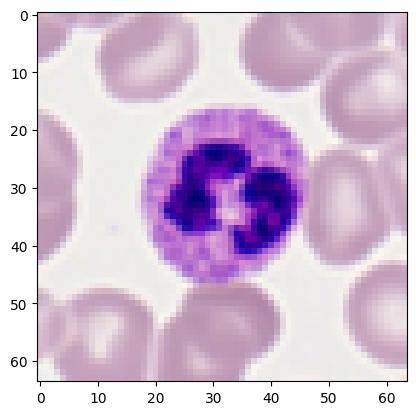

In [3]:
img = mpimg.imread('/content/drive/MyDrive/Blood_Cancer/Sample_1110.tiff')

plt.imshow(img)

In [4]:
BATCH_SIZE = 32
EPOCHS = 20
IMG_SIZE = 224

In [5]:
from skimage.feature import graycomatrix, graycoprops

def compute_glcm_features(image_gray_np):
    glcm = graycomatrix(image_gray_np, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    return contrast, energy, homogeneity, correlation



Median Filtering Time: 0.0112 seconds
Otsu Thresholding Time: 0.0180 seconds


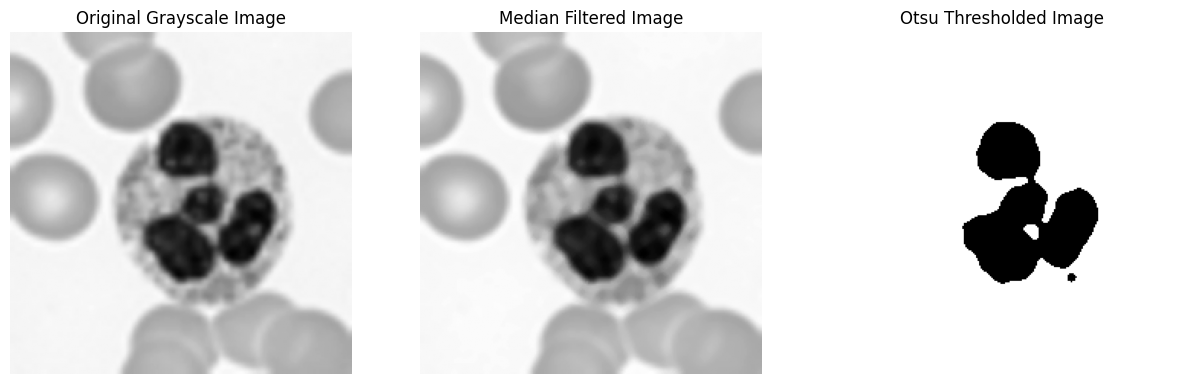

GLCM Features After Median Filter:
Contrast: 19.558215887251762
Energy: 0.18306704541424912
Homogeneity: 0.6094058349887087
Correlation: 0.9962246595232623
Image 1/100: Preproc=0.3141s | Median=0.0007s | GLCM=0.0042s | Otsu=0.0005s | Total=0.3195s
Image 2/100: Preproc=0.2283s | Median=0.0003s | GLCM=0.0030s | Otsu=0.0004s | Total=0.2321s
Image 3/100: Preproc=0.8681s | Median=0.0008s | GLCM=0.0043s | Otsu=0.0008s | Total=0.8740s
Image 4/100: Preproc=0.2510s | Median=0.0007s | GLCM=0.0044s | Otsu=0.0007s | Total=0.2569s
Image 5/100: Preproc=0.2313s | Median=0.0003s | GLCM=0.0036s | Otsu=0.0007s | Total=0.2359s
Image 6/100: Preproc=0.2172s | Median=0.0005s | GLCM=0.0034s | Otsu=0.0007s | Total=0.2217s
Image 7/100: Preproc=0.2252s | Median=0.0007s | GLCM=0.0041s | Otsu=0.0007s | Total=0.2307s
Image 8/100: Preproc=0.1912s | Median=0.0005s | GLCM=0.0042s | Otsu=0.0007s | Total=0.1967s
Image 9/100: Preproc=0.2184s | Median=0.0003s | GLCM=0.0037s | Otsu=0.0008s | Total=0.2231s
Image 10/100: Pr

In [6]:
import time
def preprocess_image(image_path):
    image = Image.open(image_path)

    if image.mode == 'RGBA':
        image = image.convert('RGB')

    image = image.resize((IMG_SIZE, IMG_SIZE))

    # Convert to grayscale
    image_gray = image.convert('L')
    image_gray_np = np.array(image_gray)

    return image_gray_np

def apply_median_filter(image_gray_np):
    # Apply median filter
    median_filtered_image = cv2.medianBlur(image_gray_np, ksize=5)

    return median_filtered_image

def compute_glcm_after_filter(median_filtered_image):
    # Compute GLCM features
    glcm = graycomatrix(median_filtered_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    return contrast, energy, homogeneity, correlation

def apply_otsu_threshold(image_gray_np):
    # Apply Otsu thresholding
    _, binary_image = cv2.threshold(image_gray_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Convert to RGB for model input
    binary_image_rgb = np.stack((binary_image,) * 3, axis=-1)
    binary_image_rgb = binary_image_rgb / 255.0

    return binary_image_rgb

# Function to display image
def display_images(original, filtered, thresholded):
    plt.figure(figsize=(15, 5))

    # Original grayscale image
    plt.subplot(1, 3, 1)
    plt.title('Original Grayscale Image')
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    # Median filtered image
    plt.subplot(1, 3, 2)
    plt.title('Median Filtered Image')
    plt.imshow(filtered, cmap='gray')
    plt.axis('off')

    # Otsu thresholded image
    plt.subplot(1, 3, 3)
    plt.title('Otsu Thresholded Image')
    plt.imshow(thresholded, cmap='gray')
    plt.axis('off')

    plt.show()

IMAGE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_1240.tiff'

image_gray_np = preprocess_image(IMAGE_PATH)

start = time.time()
median_filtered_image = apply_median_filter(image_gray_np)
end = time.time()
print(f"Median Filtering Time: {end - start:.4f} seconds")

contrast, energy, homogeneity, correlation = compute_glcm_after_filter(median_filtered_image)

start = time.time()
binary_image_rgb = apply_otsu_threshold(median_filtered_image)
end = time.time()
print(f"Otsu Thresholding Time: {end - start:.4f} seconds")

display_images(image_gray_np, median_filtered_image, binary_image_rgb)

print(f"GLCM Features After Median Filter:")
print(f"Contrast: {contrast}")
print(f"Energy: {energy}")
print(f"Homogeneity: {homogeneity}")
print(f"Correlation: {correlation}")

def load_and_preprocess_dataset(BASE_PATH, NUM_IMAGES):
    all_image_paths = [BASE_PATH.format(i) for i in range(1, NUM_IMAGES + 1)]
    processed_images = []
    glcm_features = []

    # Lists to store times for averaging
    preprocessing_times, median_times, glcm_times, otsu_times, total_times = [], [], [], [], []

    total_start = time.time()

    for idx, path in enumerate(all_image_paths, start=1):
        image_start = time.time()

        # --- Preprocessing (grayscale only) ---
        start = time.time()
        image_gray_np = preprocess_image(path)   # return only grayscale
        preprocessing_time = time.time() - start

        # --- Median Filter ---
        start = time.time()
        median_filtered_image = apply_median_filter(image_gray_np)
        median_time = time.time() - start

        # --- GLCM ---
        start = time.time()
        contrast, energy, homogeneity, correlation = compute_glcm_features(image_gray_np)
        glcm_time = time.time() - start

        # --- Otsu Thresholding ---
        start = time.time()
        binary_image_rgb = apply_otsu_threshold(median_filtered_image)
        otsu_time = time.time() - start

        processed_images.append(binary_image_rgb)
        glcm_features.append([contrast, energy, homogeneity, correlation])

        total_image_time = time.time() - image_start

        preprocessing_times.append(preprocessing_time)
        median_times.append(median_time)
        glcm_times.append(glcm_time)
        otsu_times.append(otsu_time)
        total_times.append(total_image_time)

        # Print per-image timing
        print(f"Image {idx}/{NUM_IMAGES}: "
              f"Preproc={preprocessing_time:.4f}s | "
              f"Median={median_time:.4f}s | "
              f"GLCM={glcm_time:.4f}s | "
              f"Otsu={otsu_time:.4f}s | "
              f"Total={total_image_time:.4f}s")

        # Progress every 100 images
        if idx % 100 == 0:
            elapsed = time.time() - total_start
            print(f"Processed {idx} images so far in {elapsed:.2f} seconds")

    total_end = time.time()
    dataset_total_time = total_end - total_start

    print(f"\n✅ Total Dataset Preprocessing Time ({NUM_IMAGES} images): {dataset_total_time:.2f} seconds")
    print(f"✅ Average Time per Image: {dataset_total_time / NUM_IMAGES:.4f} seconds")

    # --- Compute Averages ---
    print("\n🔎 Average Step-wise Timings:")
    print(f"Preprocessing Avg: {sum(preprocessing_times)/len(preprocessing_times):.4f}s")
    print(f"Median Filter Avg: {sum(median_times)/len(median_times):.4f}s")
    print(f"GLCM Computation Avg: {sum(glcm_times)/len(glcm_times):.4f}s")
    print(f"Otsu Thresholding Avg: {sum(otsu_times)/len(otsu_times):.4f}s")
    print(f"Total per Image Avg: {sum(total_times)/len(total_times):.4f}s")

    return np.array(processed_images), np.array(glcm_features)


NUM_IMAGES = 100
BASE_PATH = '/content/drive/MyDrive/Blood_Cancer/Sample_{}.tiff'

images, glcm_features = load_and_preprocess_dataset(BASE_PATH, NUM_IMAGES)
labels = [1] * NUM_IMAGES

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print("Training data shape:", x_train.shape)
print("Validation data shape:", x_test.shape)

# Calculate average GLCM features
mean_glcm = np.mean(glcm_features, axis=0)

contrast_avg = mean_glcm[0]
correlation_avg = mean_glcm[1]
energy_avg = mean_glcm[2]
homogeneity_avg = mean_glcm[3]

print(f"Average Contrast: {contrast_avg}")
print(f"Average Correlation: {correlation_avg}")
print(f"Average Energy: {energy_avg}")
print(f"Average Homogeneity: {homogeneity_avg}")

In [7]:
mean_glcm = np.mean(glcm_features, axis=0)

contrast_avg = mean_glcm[0]
correlation_avg = mean_glcm[1]
energy_avg = mean_glcm[2]
homogeneity_avg = mean_glcm[3]

print(f"Average Contrast: {contrast_avg}")
print(f"Average Correlation: {correlation_avg}")
print(f"Average Energy: {energy_avg}")
print(f"Average Homogeneity: {homogeneity_avg}")

Average Contrast: 16.709399623638696
Average Correlation: 0.1675253746751409
Average Energy: 0.5655732783936149
Average Homogeneity: 0.9966856054270039


In [8]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()


In [9]:
def build_mobilenet_model(input_shape):
    base_model = tf.keras.applications.MobileNet(
        input_shape=input_shape,
        include_top=False,  # We will add our custom layers on top
        weights=None
    )
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_mobilenet_model((IMG_SIZE, IMG_SIZE, 3))


In [10]:
train_generator = train_datagen.flow(x_train,y_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = val_datagen.flow(x_test,y_test, batch_size=BATCH_SIZE, shuffle=False)


import time

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    validation_steps=len(x_test) // BATCH_SIZE,
    epochs=EPOCHS
)

end_time = time.time()

# Calculate total training time
total_training_time = end_time - start_time
print(f"Total Training Time: {total_training_time:.2f} seconds")

# Calculate average time per epoch
average_time_per_epoch = total_training_time / EPOCHS
print(f"Average Time per Epoch: {average_time_per_epoch:.2f} seconds")

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 77s 36s/step - accuracy: 0.4792 - loss: 0.5879 - val_accuracy: 1.0000 - val_loss: 0.6506
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 4.1286e-05 - val_accuracy: 1.0000 - val_loss: 0.6230
Epoch 3/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step - accuracy: 1.0000 - loss: 1.3149e-06 - val_accuracy: 1.0000 - val_loss: 0.5553
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 1.0397e-07 - val_accuracy: 1.0000 - val_loss: 0.5164
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step - accuracy: 1.0000 - loss: 4.7256e-09 - val_accuracy: 1.0000 - val_loss: 0.4319
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 2.9894e-09 - val_accuracy: 1.0000 - val_loss: 0.3889
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step - accuracy: 1.0000 - loss: 3.8406e-10 - val_accuracy: 1.0000 - val_loss: 0.3050
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 5.4622e-12 - val_accuracy: 1.0000 - val_loss: 0.2653
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 1.0000 - loss: 7.3387e-11 - val_accuracy: 1.0000 - val_loss: 0.1959
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 5.6883e-11 - val_accuracy: 

In [11]:
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_acc*100:.2f}%')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 0.0074
Validation Accuracy: 100.00%


In [12]:
mobilenet_training_time = 233.34  # seconds
resnet_training_time = 152.54  # seconds

# Calculate the time difference and percentage faster
time_difference = resnet_training_time - mobilenet_training_time
percentage_faster = (time_difference / resnet_training_time) * 100

time_difference, percentage_faster

(-80.80000000000001, -52.96971286220009)